# MSDS 686 Capstone | Drone vs Bird Classification : Model Development: CNN Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

DATA_RAW   = '../data/raw'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

# Recalculate class weights directly
BIRD_DIR  = os.path.join(DATA_RAW, 'birds')
DRONE_DIR = os.path.join(DATA_RAW, 'drones')
n_birds  = len([f for f in os.listdir(BIRD_DIR)  if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
n_drones = len([f for f in os.listdir(DRONE_DIR) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
n_total  = n_birds + n_drones
class_weight = {0: n_total / (2 * n_birds), 1: n_total / (2 * n_drones)}

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')
print(f'Birds: {n_birds} | Drones: {n_drones} | Total: {n_total}')
print(f'Class weights: {class_weight}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


TensorFlow: 2.20.0
GPU: []
Birds: 1607 | Drones: 2499 | Total: 4106
Class weights: {0: 1.2775357809583074, 1: 0.8215286114445778}


## 1.3 Data Preprocessing Pipeline

Based on our EDA, I decided to conduct the following preprocessing choices:
- **224x224 resize** : standard size for pretrained models
- **[0,1] normalization** : stabilizes gradient descent
- **80/10/10 train/val/test split** : val for monitoring, test held out until final evaluation only
- **Class weights** : compensates for 60/40 imbalance without modifying the data
- **Augmentation on training set only**

In [2]:
# ── Normalization & Augmentation ───────────────────────────────────────────────
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

# ── Load datasets ──────────────────────────────────────────────────────────────
# 80% training
train_ds = keras.utils.image_dataset_from_directory(
    DATA_RAW,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Remaining 20% split evenly into val (10%) and test (10%)
val_ds_full = keras.utils.image_dataset_from_directory(
    DATA_RAW,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

CLASS_NAMES  = train_ds.class_names
val_batches  = tf.data.experimental.cardinality(val_ds_full)
val_ds  = val_ds_full.take(val_batches // 2)
test_ds = val_ds_full.skip(val_batches // 2)

# Normalize all splits; augment training only
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y:   (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y:  (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

# Augmented training set (used during model.fit)
train_ds_aug = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

print(f'Class names: {CLASS_NAMES}  (0=birds, 1=drones)')
print(f'Train batches: {tf.data.experimental.cardinality(train_ds)}')
print(f'Val batches:   {tf.data.experimental.cardinality(val_ds)}')
print(f'Test batches:  {tf.data.experimental.cardinality(test_ds)}')
print('Preprocessing pipeline ready.')

Found 4104 files belonging to 2 classes.
Using 3284 files for training.
Found 4104 files belonging to 2 classes.
Using 820 files for validation.
Class names: ['birds', 'drones']  (0=birds, 1=drones)
Train batches: 103
Val batches:   13
Test batches:  13
Preprocessing pipeline ready.


Only two images didn't load, probably due to file corruption or an unsupported encoding that Keras rejects silently. At 0.05% of the dataset this has no meaningful impact on results.

## Shared Utilities

In [3]:
def plot_training_curves(history, title):
    """Plot accuracy and loss curves for train and validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train', color='#3498db')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='#e74c3c')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', color='#3498db')
    axes[1].plot(history.history['val_loss'], label='Val',   color='#e74c3c')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, dataset, split_name):
    """Evaluate model and print accuracy + AUC."""
    loss, acc, auc = model.evaluate(dataset, verbose=0)
    print(f'  {split_name} — Accuracy: {acc:.4f} | AUC: {auc:.4f}')
    return acc, auc

---
## Part 2: Model Development

## 2.1 Experiment 0 : Architecture Review: Parameter Explosion

**Hypothesis:** Before training, I reviewed the model summary and found that using Flatten after the final conv block produced a feature vector of 100,352 values. Connecting this to Dense(128) created 12.8M parameters for a dataset of only 3,284 training images. This ratio would cause severe overfitting before the model learned anything meaningful.

In [16]:
def build_simple_cnn():
    model = keras.Sequential([
        keras.Input(shape=(224, 224, 3)),

        # Block 1: detect low-level features (edges, textures)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        # Block 2: detect mid-level features (shapes, patterns)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        # Block 3: detect high-level features (object parts)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),          # regularize to reduce overfitting
        layers.Dense(1, activation='sigmoid')  # binary output
    ], name='simple_cnn')
    return model

model_v1 = build_simple_cnn()
model_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_v1.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

### Experiment 0 Log

**Date:** March 7, 2026

**Architecture:** Original LLM-suggested architecture, 3-block CNN (32→64→128), Flatten, Dense(128), Dropout(0.5), sigmoid, 12,938,561 parameters

**Hyperparameters:** None as the model was not trained yet. Issue was identified at architecture review stage.

**Hypothesis:** Before training, I reviewed the model summary and found that using Flatten after the final conv block produced a feature vector of 100,352 values. Connecting this to Dense(128) created 12.8M parameters for a dataset of only 3,284 training images. This ratio would cause severe overfitting before the model learned anything meaningful.

**LLM Input?** Not an LLM suggestion, my decision motivated by overfitting observed. The LLM confirmed and produced solutions, Replaced Flatten with GlobalAveragePooling2D.

**Conclusions:** *LLM-suggested architectures must be reviewed before training. Flatten is appropriate for large datasets, for small datasets like this one, GlobalAveragePooling2D is the right choice. This is an example where accepting the LLM output without inspection would have produced a broken experiment.
Next steps: 

**Next steps:** Proceed to Experiment 1 with the corrected architecture.

---

## 2.2 Experiment 1 : Simple CNN from Scratch

**Hypothesis:** A 3-block CNN with increasing filter depth (32→64→128) should learn enough spatial features, edges, textures, shapes, to substantially beat the logistic regression baseline of 82.7%. I built the architecture based on standard practice for binary image classification to start simple and then iterate.

In [ ]:
def build_simple_cnn():
    model = keras.Sequential([
        keras.Input(shape=(224, 224, 3)),

        # Block 1: detect low-level features (edges, textures)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        # Block 2: detect mid-level features (shapes, patterns)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        # Block 3: detect high-level features (object parts)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),          # regularize to reduce overfitting
        layers.Dense(1, activation='sigmoid')  # binary output
    ], name='simple_cnn')
    return model

model_v1 = build_simple_cnn()
model_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_v1.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Training Experiment 1: Simple CNN...
Epoch 1/20


103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 344ms/step - accuracy: 0.6270 - auc: 0.6990 - loss: 0.6157 - val_accuracy: 0.7115 - val_auc: 0.8214 - val_loss: 0.5848
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 35s 337ms/step - accuracy: 0.7506 - auc: 0.7917 - loss: 0.5373 - val_accuracy: 0.7909 - val_auc: 0.8139 - val_loss: 0.5021
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 352ms/step - accuracy: 0.7734 - auc: 0.8187 - loss: 0.4996 - val_accuracy: 0.8221 - val_auc: 0.8486 - val_loss: 0.4431
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 35s 343ms/step - accuracy: 0.7847 - auc: 0.8388 - loss: 0.4762 - val_accuracy: 0.8197 - val_auc: 0.8728 - val_loss: 0.4561
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 37s 356ms/step - accuracy: 0.8045 - auc: 0.8480 - loss: 0.4650 - val_accuracy: 0.8317 - val_auc: 0.8799 - val_loss: 0.4435
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 37s 356ms/step - accuracy: 0.8103 - auc: 0.8627 - loss: 0.4515 - val_accuracy: 0.8101 - val_auc: 0.8822 - val_loss: 0.4165
Epoch 7/20
103/103 ━━━━━━━━━━━━━━

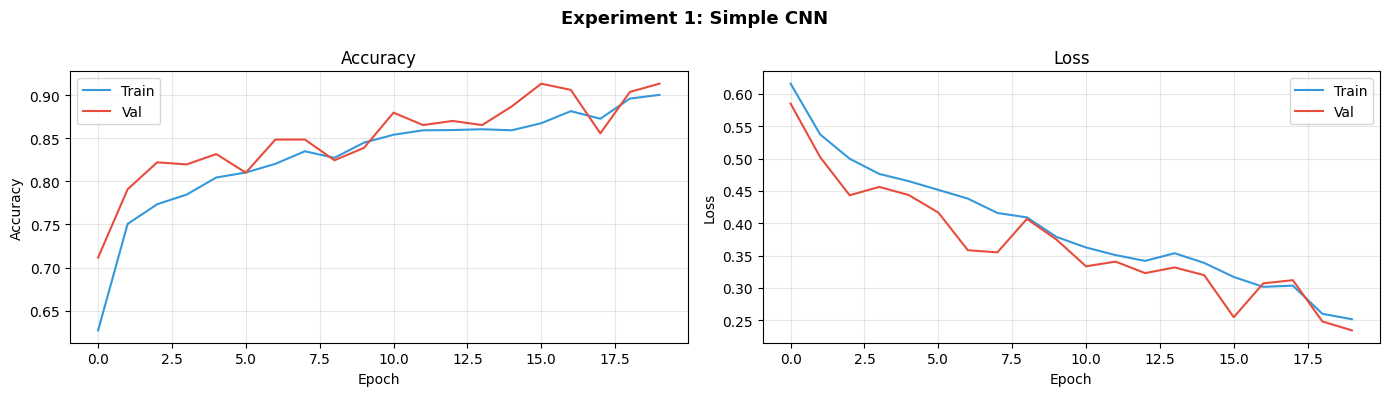


Experiment 1 Results:
  Validation — Accuracy: 0.9135 | AUC: 0.9650
Model saved.


In [8]:
print('Training Experiment 1: Simple CNN...')
history_v1 = model_v1.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
        )
    ],
    verbose=1
)

plot_training_curves(history_v1, 'Experiment 1: Simple CNN')
print('\nExperiment 1 Results:')
val_acc_v1, val_auc_v1 = evaluate_model(model_v1, val_ds, 'Validation')
model_v1.save(os.path.join(MODELS_DIR, 'exp1_simple_cnn.keras'))
print('Model saved.')

### Experiment 1 Log

**Date:** March 9, 2026

**Architecture:** 3-block CNN (32→64→128 filters), GlobalAveragePooling2D, Dense(128), Dropout(0.5), sigmoid output, 109,889 parameters

**Hyperparameters:** Adam lr=1e-3, batch=32, max 20 epochs, EarlyStopping(patience=4)

**Hypothesis:** Spatial feature learning should substantially beat the 82.7% logistic regression baseline.

**LLM Input?** Architecture suggested by LLM and fine-tuned before training. LLM used Flatten (12.9M params) which is too much considering the limited dataset size, I asked for alternative solutions and chose replacing Flatten with GlobalAveragePooling2D (110K params) to prevent overfitting.

**Results:**
- Training accuracy (epoch 20): 90.0%
- Validation accuracy: 91.4%
- Validation AUC: 0.965

**Observations:** The model ran all 20 epochs without EarlyStopping triggering, meaning it was still improving at the end. Train and val accuracy increased closely together throughout so no meaningful overfitting gap. Val accuracy exceeded train accuracy multiple times which may be because augmentation was making training harder than validation. The model beat the logistic regression baseline by 8.7 percentage points in accuracy.

**Conclusions:** A simple 3-block CNN trains stably and generalizes well. The fact that it was still learning at epoch 20 suggests more capacity or more epochs could help.

**Next steps:** Add BatchNormalization after each Conv block, add a 4th block (256 filters), and add ReduceLROnPlateau to better exploit the learning rate during training.

---

## 2.3 Experiment 2 : CNN + BatchNormalization

**Hypothesis:** BatchNorm after each Conv layer normalizes activations and stabilizes gradients allowing the model to train faster and generalize better. Adding a 4th conv block (256 filters) gives the model more representational capacity to detect complex drone vs bird features. And ReduceLROnPlateau added to automatically reduce the learning rate when progress stalls, for more performance out of each training run.

**Changes from Exp 1:** BatchNorm after every Conv, 4th conv block (256 filters), Dense(128)→Dense(256), Dropout(0.5)→Dropout(0.4), added ReduceLROnPlateau callback, epochs increased to 30 since last time it kept removing at 20.

**LLM Input?** BatchNorm or 4th block suggested by LLM but I implemented both. Epochs increase to 30 was my decision based on Exp 1 still improving at epoch 20.

In [10]:
def build_cnn_batchnorm():
    model = keras.Sequential([
        keras.Input(shape=(224, 224, 3)),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2),

        # Block 4 — added depth
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),  # replaces Flatten — fewer params, less overfitting

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ], name='cnn_batchnorm')
    return model

model_v2 = build_cnn_batchnorm()
model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_v2.summary()

Model: "cnn_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Training Experiment 2: CNN + BatchNorm...
Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 85s 809ms/step - accuracy: 0.8045 - auc: 0.8784 - loss: 0.4416 - val_accuracy: 0.6394 - val_auc: 0.7099 - val_loss: 0.7878 - learning_rate: 0.0010
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 83s 807ms/step - accuracy: 0.8520 - auc: 0.9252 - loss: 0.3525 - val_accuracy: 0.6779 - val_auc: 0.7138 - val_loss: 0.7895 - learning_rate: 0.0010
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.8769 - auc: 0.9388 - loss: 0.3165
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
103/103 ━━━━━━━━━━━━━━━━━━━━ 77s 748ms/step - accuracy: 0.8666 - auc: 0.9362 - loss: 0.3251 - val_accuracy: 0.7308 - val_auc: 0.7800 - val_loss: 0.8136 - learning_rate: 0.0010
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 74s 717ms/step - accuracy: 0.9035 - auc: 0.9600 - loss: 0.2562 - val_accuracy: 0.8101 - val_auc: 0.9125 - val_loss: 0.3801 - learning_rate: 5.0000e-04
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━

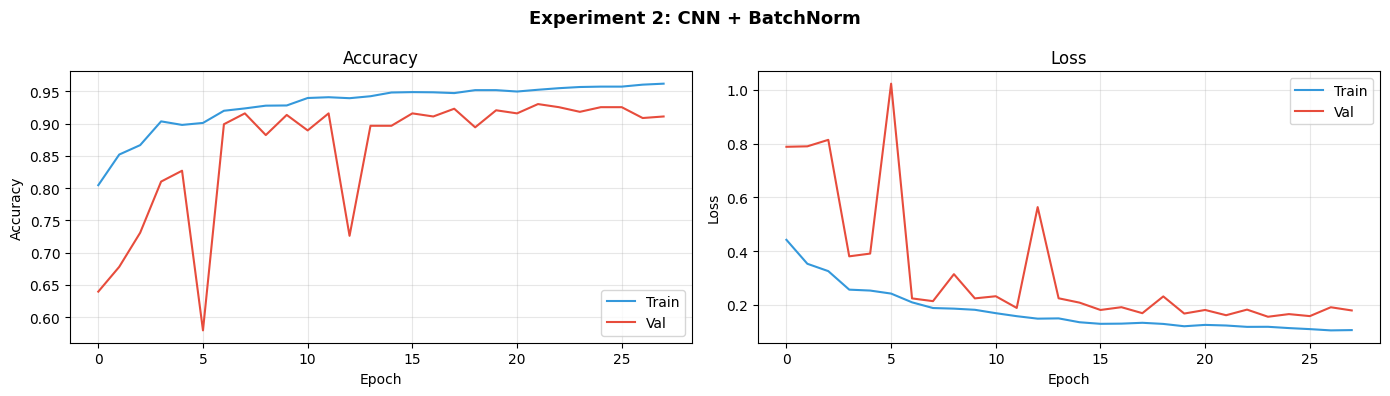


Experiment 2 Results:
  Validation — Accuracy: 0.9183 | AUC: 0.9852
Model saved.


In [11]:
print('Training Experiment 2: CNN + BatchNorm...')
history_v2 = model_v2.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
        )
    ],
    verbose=1
)

plot_training_curves(history_v2, 'Experiment 2: CNN + BatchNorm')
print('\nExperiment 2 Results:')
val_acc_v2, val_auc_v2 = evaluate_model(model_v2, val_ds, 'Validation')
model_v2.save(os.path.join(MODELS_DIR, 'exp2_cnn_batchnorm.keras'))
print('Model saved.')

### Experiment 2 Log

**Date:** March 9, 2026

**Architecture:** 4-block CNN (32→64→128→256), BatchNorm after each Conv, GlobalAveragePooling2D, Dense(256), Dropout(0.4), sigmoid, increase to 456,385 parameters

**Hyperparameters:** Adam lr=1e-3, batch=32, max 30 epochs, EarlyStopping(patience=4), ReduceLROnPlateau(factor=0.5, patience=2)

**Hypothesis:** BatchNorm stabilizes training and reduces the train/val gap further. More depth (4th block) gives the model capacity to learn more complex features.

**LLM Input?** BatchNorm or 4th block suggested by LLM. Epoch increase to 30 was my own decision based on Exp 1 still improving at epoch 20.

**Results:**
- Training accuracy (best epoch): 95.7%
- Validation accuracy (best epoch 24): 91.8%
- Validation AUC: 0.985
- EarlyStopping triggered at epoch 28, restored weights from epoch 24

**Observations:** The first 3 epochs showed unstable val loss while BatchNorm's running statistics were stabilizing which is fine and expected. ReduceLROnPlateau reduced the learning rate 5 times across training causing recovery in val loss. The train/val accuracy gap widened slightly compared to Exp 1, indicating pretty mild overfitting. The AUC improvement from 0.965 to 0.985 is a very meaningful result, BatchNorm significantly improved the model's ability to separate the two classes even when accuracy gains were modest.

**Conclusions:** BatchNorm + additional depth improved AUC significantly (+0.020) with low accuracy gain (+0.4%) but gain nontheless. The mild overfitting suggests we are close to a limit of what a CNN trained from scratch can achieve on this dataset. Transfer learning in 04_Final.ipynb should provide another significant leap by leveraging ImageNet features.

**Next steps:** Transfer Learning MobileNetV2 pretrained on ImageNet.

---

## 2.2 Experiment Tracking Log

| Exp # | Description | Val Acc | Val AUC | LLM Input | Notes |
|-------|-------------|---------|---------|------------|-------|
| Baseline 0 | Naive majority class | 60.9% | 0.500 | None | Always predicts drone |
| Baseline 1 | Logistic Regression | 82.7% | 0.919 | None | No spatial reasoning |
| 1 | Simple CNN — 3 blocks, GAP | 91.4% | 0.965 | Full architecture, required iterations | Beat LR baseline by +8.7pp |
| 2 | CNN + BatchNorm — 4 blocks | 91.8% | 0.985 | BatchNorm accepted | AUC +0.020 over Exp 1 |

## CNN Experiments Summary

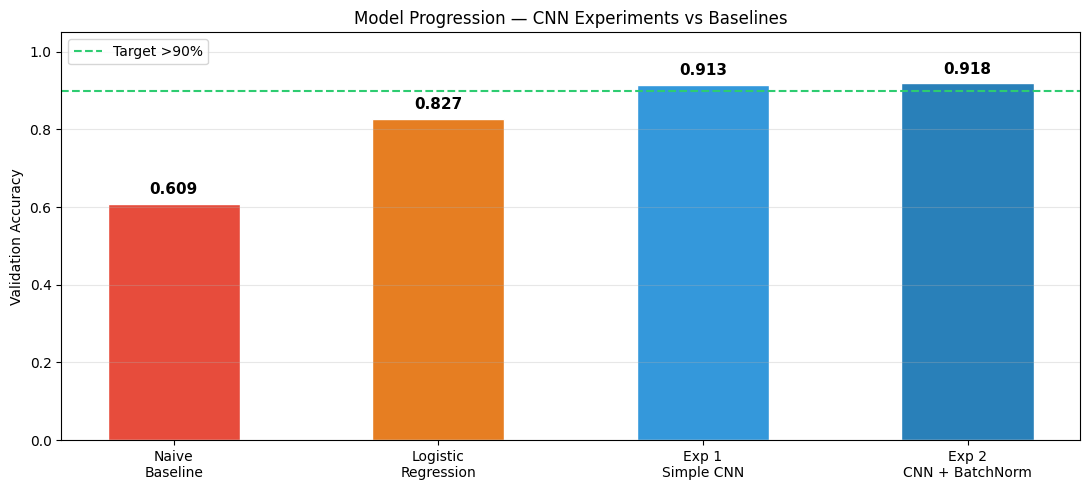

CNN EXPERIMENTS SUMMARY
  Naive baseline:          0.6086 accuracy | 0.5000 AUC
  Logistic Regression:     0.8267 accuracy | 0.9188 AUC
  Exp 1 — Simple CNN:      0.9135 accuracy | 0.9650 AUC
  Exp 2 — CNN + BatchNorm: 0.9183 accuracy | 0.9852 AUC

  Best CNN improvement over LR baseline: +9.2pp

  Next: Transfer Learning (MobileNetV2) in 04_Final.ipynb


In [15]:
# ── Compare both CNN experiments against baselines ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

bar_labels = [
    'Naive\nBaseline',
    'Logistic\nRegression',
    'Exp 1\nSimple CNN',
    'Exp 2\nCNN + BatchNorm'
]
values = [0.609, 0.827, val_acc_v1, val_acc_v2]
colors = ['#e74c3c', '#e67e22', '#3498db', '#2980b9']

bars = ax.bar(bar_labels, values, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=11, fontweight='bold')
ax.axhline(y=0.9, color='#2ecc71', linestyle='--', linewidth=1.5, label='Target >90%')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Validation Accuracy')
ax.set_title('Model Progression — CNN Experiments vs Baselines', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('CNN EXPERIMENTS SUMMARY')
print('=' * 55)
print(f'  Naive baseline:          0.6086 accuracy | 0.5000 AUC')
print(f'  Logistic Regression:     0.8267 accuracy | 0.9188 AUC')
print(f'  Exp 1 — Simple CNN:      {val_acc_v1:.4f} accuracy | {val_auc_v1:.4f} AUC')
print(f'  Exp 2 — CNN + BatchNorm: {val_acc_v2:.4f} accuracy | {val_auc_v2:.4f} AUC')
print()
best_cnn_acc = max(val_acc_v1, val_acc_v2)
print(f'  Best CNN improvement over LR baseline: +{(best_cnn_acc - 0.8267)*100:.1f}pp')
print()
print('  Next: Transfer Learning (MobileNetV2) in 04_Final.ipynb')

### Model Summary

This notebook established two CNN baselines trained from scratch on the drone vs bird dataset.

1. CNNs substantially beat logistic regression. Both CNN experiments cleared the 82.7% logistic regression baseline, confirming the CNN learned genuine structural features.

2. Architecture decisions before training matter. The original LLM-suggested architecture had 12.9M parameters for a dataset of 3,284 images which would have consumed time and compute and caused overfitting. The LLM's suggestions should always be verified.

3. BatchNorm contributed a lot to AUC, not so much to accuracy. Experiment 2 improved accuracy by only 0.4 but improved AUC by 0.020. This means the model became much better at ranking confidence scores. This is great for my problem statement, for a security application like drone detection, accurate confidence matters a lot.